In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sys
print(sys.executable)

/home/kirollos/data_projects/.venv/bin/python


In [4]:
df = pd.read_csv("Books_Data_Clean.csv")

In [5]:
df.head()

,index,Publishing Year,Book Name,Author,language_code,Author_Rating,Book_average_rating,Book_ratings_count,genre,gross sales,publisher revenue,sale price,sales rank,Publisher,units sold
0,0,1975.0,Beowulf,"Unknown, Seamus Heaney",en-US,Novice,3.42,155903,genre fiction,34160.0,20496.0,4.88,1,HarperCollins Publishers,7000
1,1,1987.0,Batman: Year One,"Frank Miller, David Mazzucchelli, Richmond Lew...",eng,Intermediate,4.23,145267,genre fiction,12437.5,7462.5,1.99,2,HarperCollins Publishers,6250
2,2,2015.0,Go Set a Watchman,Harper Lee,eng,Novice,3.31,138669,genre fiction,47795.0,28677.0,8.69,3,"Amazon Digital Services, Inc.",5500
3,3,2008.0,When You Are Engulfed in Flames,David Sedaris,en-US,Intermediate,4.04,150898,fiction,41250.0,24750.0,7.50,3,Hachette Book Group,5500
4,4,2011.0,Daughter of Smoke & Bone,Laini Taylor,eng,Intermediate,4.04,198283,genre fiction,37952.5,22771.5,7.99,4,Penguin Group (USA) LLC,4750


In [6]:
df.describe()

,index,Publishing Year,Book_average_rating,Book_ratings_count,gross sales,publisher revenue,sale price,sales rank,units sold
count,1070.000000,1069.000000,1070.000000,1070.000000,1070.000000,1070.000000,1070.000000,1070.000000,1070.000000
mean,534.500000,1971.377923,4.007000,94909.913084,1856.622944,843.281030,4.869561,611.652336,9676.980374
std,309.026698,185.080257,0.247244,31513.242518,3936.924240,2257.596743,3.559919,369.849830,15370.571306
min,0.000000,-560.000000,2.970000,27308.000000,104.940000,0.000000,0.990000,1.000000,106.000000
25%,267.250000,1985.000000,3.850000,70398.000000,372.465000,0.000000,1.990000,287.500000,551.250000
50%,534.500000,2003.000000,4.015000,89309.000000,809.745000,273.078000,3.990000,595.500000,3924.000000
75%,801.750000,2010.000000,4.170000,113906.500000,1487.957500,721.180500,6.990000,932.500000,5312.250000
max,1069.000000,2016.000000,4.770000,206792.000000,47795.000000,28677.000000,33.860000,1273.000000,61560.000000


In [7]:
df =df [df["Publishing Year" ]>1900]

In [8]:
df.isna().sum ()

index                   0
Publishing Year         0
Book Name              21
Author                  0
language_code          49
Author_Rating           0
Book_average_rating     0
Book_ratings_count      0
genre                   0
gross sales             0
publisher revenue       0
sale price              0
sales rank              0
Publisher               0
units sold              0
dtype: int64

In [12]:
df.dropna(subset ="Book Name", inplace =True )

In [13]:
df.duplicated ().sum()

np.int64(0)

In [18]:
df.nunique()

index                  988
Publishing Year        101
Book Name              987
Author                 669
language_code            8
Author_Rating            4
Book_average_rating    133
Book_ratings_count     983
genre                    4
gross sales            774
publisher revenue      570
sale price             143
sales rank             818
Publisher                9
units sold             470
dtype: int64

<function matplotlib.pyplot.show(close=None, block=None)>

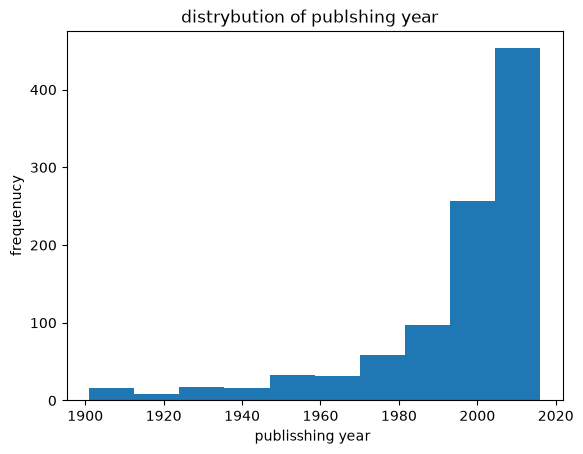

In [22]:
plt.hist(df["Publishing Year"])
plt.xlabel ("publisshing year ")
plt.ylabel("frequenucy")
plt.title("distrybution of publshing year  ")
plt.show

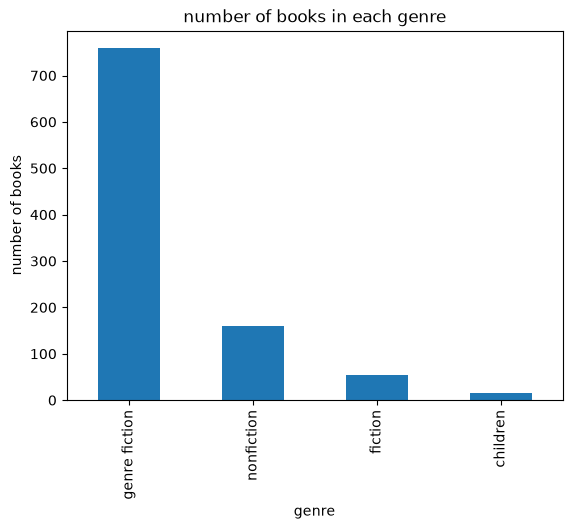

<function matplotlib.pyplot.show(close=None, block=None)>

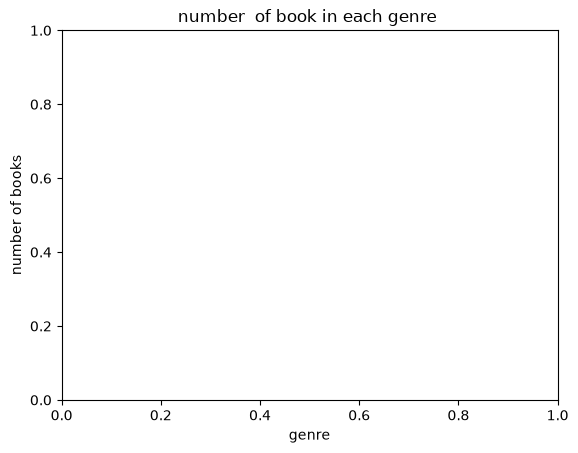

In [25]:
df["genre"].value_counts().plot(kind="bar")
plt.xlabel("genre")
plt.ylabel("number of books")
plt.title("number of books in each genre")
plt.show()
plt.xlabel("genre")
plt.ylabel("number of books")
plt.title("number  of book in each genre ")
plt.show

In [8]:
df.groupby("Author")["Book_average_rating"].mean().sort_values(ascending=False)

Author
Bill Watterson                  4.650
Bill Watterson, G.B. Trudeau    4.610
J.R.R. Tolkien                  4.590
George R.R. Martin              4.560
Sarah J. Maas                   4.526
                                ...  
Audrey Niffenegger              3.230
Herman Koch, Sam Garrett        3.220
P.D. James                      3.210
Stephen Crane                   3.210
Sue Monk Kidd                   3.100
Name: Book_average_rating, Length: 735, dtype: float64

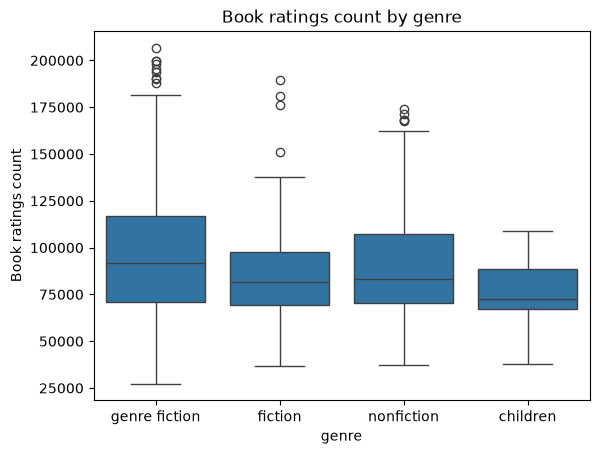

In [13]:
import seaborn as sns

sns.boxplot(x="genre", y="Book_ratings_count", data=df)
import matplotlib.pyplot as plt
plt.xlabel("genre")
plt.ylabel("Book ratings count")
plt.title("Book ratings count by genre")
plt.show()

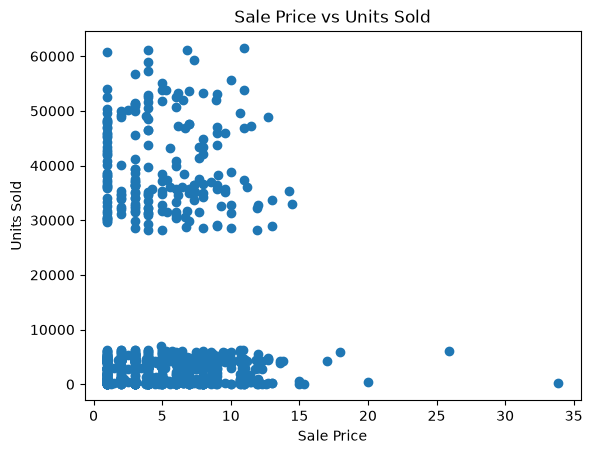

In [14]:
plt.scatter(df["sale price"], df["units sold"])
plt.xlabel("Sale Price")
plt.ylabel("Units Sold")
plt.title("Sale Price vs Units Sold")
plt.show()

In [19]:
language_code = df["language_code"].value_counts()

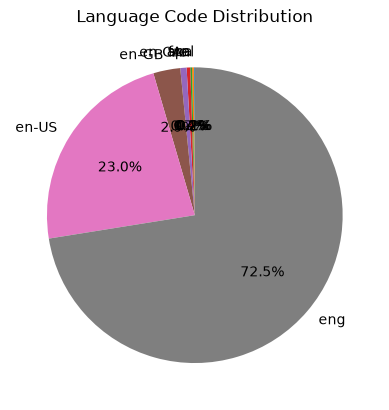

In [21]:
plt.pie(language_code, labels=language_code.index, startangle=90, autopct="%1.1f%%")
plt.title("Language Code Distribution")
plt.show()

In [27]:
df.columns = df.columns.str.strip()
df.groupby("Publisher")["publisher revenue"].sum().sort_values(ascending=False)

Publisher
Penguin Group (USA) LLC                 213817.482
Random House LLC                        189585.222
Amazon Digital Services,  Inc.          148244.178
Hachette Book Group                     137874.498
HarperCollins Publishers                128478.258
Simon and Schuster Digital Sales Inc     46988.352
Macmillan                                32356.236
HarperCollins Publishing                  2830.806
HarperCollins Christian Publishing        2135.670
Name: publisher revenue, dtype: float64

In [ ]:
df.groupby("author_rating")["book_ratings_count"].mean().sort_values(ascending=False).max()

In [29]:
df.groupby("language_code").size().sort_values(ascending=False)

language_code
eng      737
en-US    234
en-GB     30
en-CA      7
fre        4
ara        2
spa        2
nl         1
dtype: int64

In [33]:
df.groupby("Author_Rating")["Book_ratings_count"].var()


Author_Rating
Excellent       4.380998e+08
Famous          1.172260e+09
Intermediate    1.166913e+09
Novice          1.025853e+09
Name: Book_ratings_count, dtype: float64

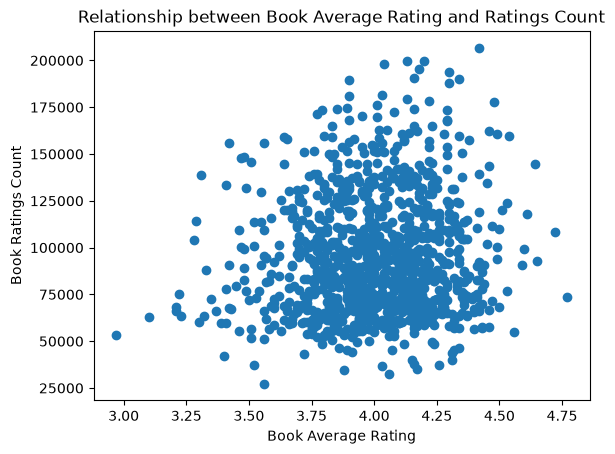

In [34]:
plt.scatter(df["Book_average_rating"], df["Book_ratings_count"])
plt.xlabel("Book Average Rating")
plt.ylabel("Book Ratings Count")
plt.title("Relationship between Book Average Rating and Ratings Count")
plt.show()

In [37]:
total_gross_sales_by_author = df.groupby(author_col)["gross sales"].sum()

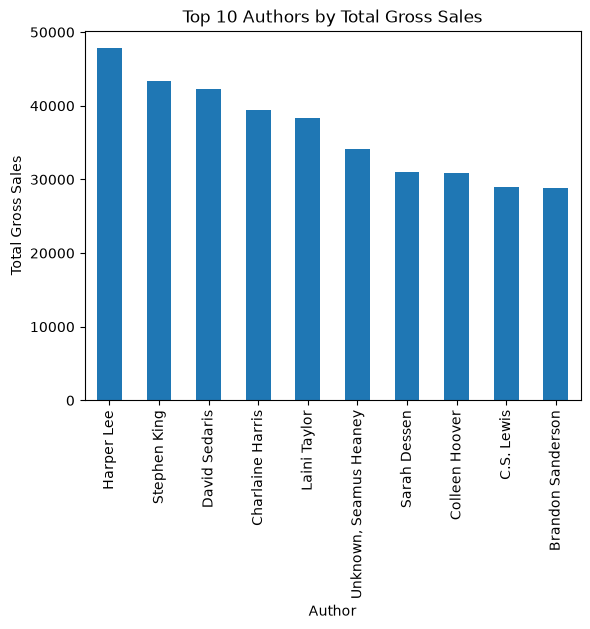

In [41]:
total_gross_sales_by_author .sort_values(ascending=False).head(10) .plot(kind="bar")
plt.xlabel("Author")
plt.ylabel("Total Gross Sales")
plt.title("Top 10 Authors by Total Gross Sales")
plt.show()

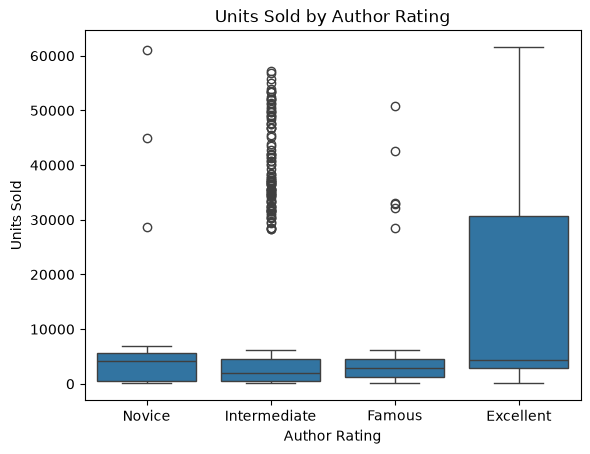

In [44]:
sns.boxplot(x="Author_Rating", y="units sold", data=df)
plt.xlabel("Author Rating")
plt.ylabel("Units Sold")
plt.title("Units Sold by Author Rating")
plt.show()


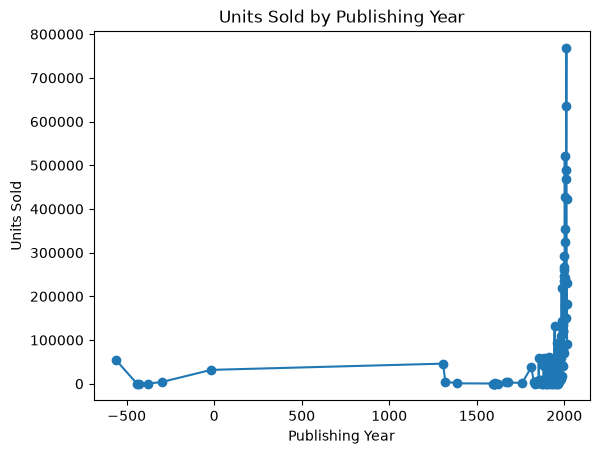

In [53]:
df.groupby("Publishing Year")["units sold"].sum().plot(kind="line", marker="o")
plt.xlabel("Publishing Year")
plt.ylabel("Units Sold")
plt.title("Units Sold by Publishing Year")
plt.show()


In [ ]:
plt

Text(0.5, 1.0, 'distrybution of publshing year  ')

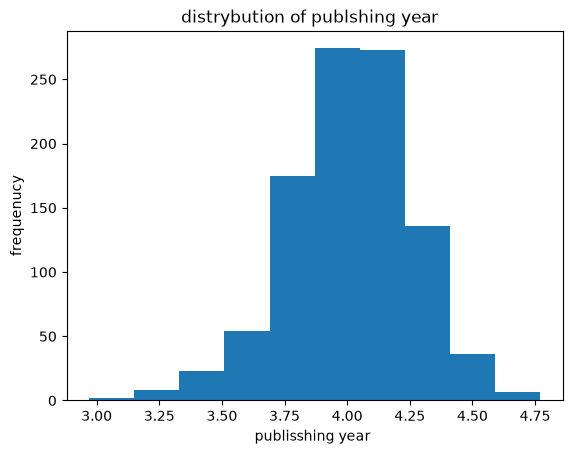

In [21]:
plt.hist(df["Book_average_rating"])
plt.xlabel("publisshing year ")
plt.ylabel("frequenucy")
plt.title("distrybution of publshing year  ")